In [1]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import torch as t
import seaborn as sns
import sys
from scipy.stats import hypergeom
from pprint import pprint

sys.path.insert(0, '..')
from evaluate_circuit import get_edge_list, get_node_list
from config_act_patch import dim_layer_pos_dict, dim_layer_map

In [2]:
model_dims_dict = {
    'google/gemma-2-2b-it': 2304,
    'meta-llama/Llama-3.2-3B-Instruct': 3072
}

plot main plot sparsity stuff of gemma 2 on various learned vectors

In [3]:
dim_dropouts = [0, 267, 764, 1225, 1928, 2186, 2254]
ntp_dropouts = [0, 217, 628, 1001, 1722, 2077, 2218]
po_dropouts = [0, 251, 741, 1158, 1863, 2175, 2266]
rtols = [0, 0.1, 0.3, 0.5, 1, 1.5, 2]

In [4]:
# get dim results
def get_sparse_results(thresh_type, vals, exp_name, model_path):
    results = []
    vector_dir = f"../pipeline/runs/{model_path.split('/')[-1]}/"
    layer, pos = dim_layer_pos_dict[model_path][dim_layer_map[model_path]]

    for r in vals:
        if r == 0:
            completions_dir = f'completions_layer{layer}_pos{pos}'
        else:
            completions_dir = f'completions_{exp_name}_{thresh_type}={r}'
        # alpaca
        with open(os.path.join(vector_dir, completions_dir, 'harmless_actadd_evaluations.json'), 'r') as f:
            data = json.load(f)
        a_asr = data["substring_matching_success_rate"]

        # jailbreakbench
        with open(os.path.join(vector_dir, completions_dir, 'jailbreakbench_actadd_evaluations.json'), 'r') as f:
            data = json.load(f)
        jbb_asr = data["llamaguard2_success_rate"]

        # strongreject
        with open(os.path.join(vector_dir, completions_dir, 'strongreject_actadd_evaluations.json'), 'r') as f:
            data = json.load(f)
        sr_asr = data["llamaguard2_success_rate"]
        results.append((a_asr, jbb_asr, sr_asr))

    return results



In [41]:
model_path = 'google/gemma-2-2b-it'

dim_rtol_results = get_sparse_results('rtol', rtols, 'dim_logit', model_path)
dim_dropout_results = get_sparse_results('dropout', dim_dropouts, 'dim_logit', model_path)
ntp_rtol_results = get_sparse_results('rtol', rtols, 'ntp_logit', model_path)
ntp_dropout_results = get_sparse_results('dropout', ntp_dropouts, 'ntp_logit', model_path)
po_rtol_results = get_sparse_results('rtol', rtols, 'reps_logit', model_path)
po_dropout_results = get_sparse_results('dropout', po_dropouts, 'reps_logit', model_path)
model_dims = model_dims_dict[model_path]

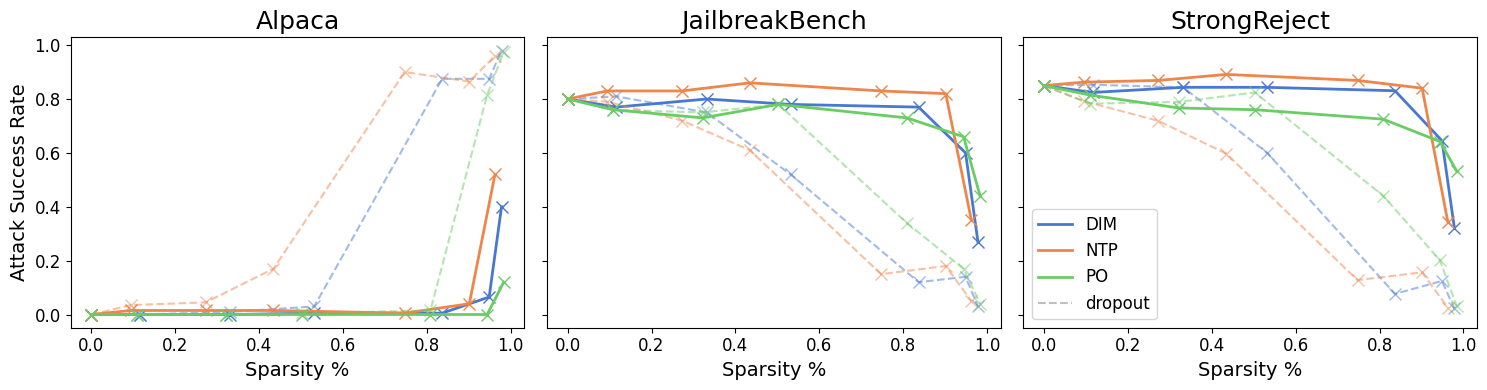

In [42]:
palette = sns.color_palette("muted", 3)
method_colors = {'DIM': palette[0], 'NTP': palette[1], 'PO': palette[2]}

datasets   = ['Alpaca', 'JailbreakBench', 'StrongReject']
ds_indices = [0, 1, 2]

# each results list is [(a_asr, jbb_asr, sr_asr), ...] with 6 entries
rtol_results    = {'DIM': dim_rtol_results,    'NTP': ntp_rtol_results,    'PO': po_rtol_results}
dropout_results = {'DIM': dim_dropout_results, 'NTP': ntp_dropout_results, 'PO': po_dropout_results}

xs_dict = {
    'DIM': [n/model_dims for n in dim_dropouts],
    'NTP': [n/model_dims for n in ntp_dropouts],
    'PO': [n/model_dims for n in po_dropouts]
}
x_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ds_name, ds_idx in zip(axes, datasets, ds_indices):
    for method, color in method_colors.items():
        rtol_vals    = [r[ds_idx] for r in rtol_results[method]]
        dropout_vals = [r[ds_idx] for r in dropout_results[method]]

        ax.plot(xs_dict[method], rtol_vals,    color=color, linestyle='-', marker='x', markersize=8, linewidth=2,   label=f'{method} (rtol)')
        ax.plot(xs_dict[method], dropout_vals, color=color, linestyle='--', marker='x', markersize=8, linewidth=1.5, alpha=0.5, label=f'{method} (dropout)')

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks, fontsize=12)
    ax.set_xlabel('Sparsity %', fontsize=14)
    ax.set_title(ds_name, fontsize=18)

axes[0].tick_params('y', labelsize=12)
axes[0].set_ylabel('Attack Success Rate', fontsize=14)

# build legend with one entry per method (solid) + one for dropout style
from matplotlib.lines import Line2D
legend_handles = [
    *[Line2D([0], [0], color=method_colors[m], linewidth=2, label=m) for m in method_colors],
    Line2D([0], [0], color='gray', linewidth=1.5, linestyle='--', alpha=0.5, label='dropout'),
]
axes[-1].legend(handles=legend_handles, fontsize=12, loc='best')

# plt.suptitle('Sparse Steering Vector Evaluation (Gemma 2 2B)', fontsize=13)
plt.tight_layout()
plt.savefig('sparsity_g2.pdf', bbox_inches='tight')
plt.show()


get similarities of sparse vectors. Is in the paper

In [17]:
# load sparse vectors
model_path = 'google/gemma-2-2b-it'
path = f"../vectors/{model_path.split('/')[-1]}"
bszs = [6, 12]
lrs = ['1e-2', '4e-2']

# load dim rtol vecs
dim_vectors = []
for i, val in enumerate(rtols):
    if i == 0:
        sparse_vec = t.load('../pipeline/runs/gemma-2-2b-it/direction_layer15_pos-1.pt', map_location='cpu').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"dim_logit_rtol={val}.pt"), map_location='cpu')['direction']
    dim_vectors.append(sparse_vec)

# load ntp rtol vecs
ntp_vectors = []
for i, val in enumerate(rtols):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/gemma-2-2b-it/ntp_bsz6_lr1e-2_seed42/direction_8.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"ntp_logit_rtol={val}.pt"), map_location='cpu')['direction']
    ntp_vectors.append(sparse_vec)

# load po rtol vecs
po_vectors = []
for i, val in enumerate(rtols):
    if i == 0:
        sparse_vec = t.load('../trained_vectors/gemma-2-2b-it/reps_bsz6_lr1e-2_ss2e-2_seed5/direction_1.pt').to(t.float32)
    else:
        sparse_vec = t.load(os.path.join(path, f"reps_logit_rtol={val}.pt"), map_location='cpu')['direction']
    po_vectors.append(sparse_vec)

0 1.0 2304 2304
0.1 0.48713076262560906 1589 1913
0.3 0.02448203321738265 881 1406
0.5 0.051602381580368215 503 1055
1 0.05798238060221249 133 524
1.5 1.045772404738335e-26 43 123
2 1.5939540593798747e-10 11 44
0 1.0 2304 2304
0.1 0.2298873155007364 1622 1930
0.3 0.0002775478173812672 968 1463
0.5 9.889255456113504e-12 638 1133
1 1.315288271067005e-13 223 595
1.5 5.863370630275953e-80 100 172
2 2.2535906686758905e-43 37 68
0 1.0 2304 2304
0.1 0.0655917824083703 1867 2070
0.3 1.8880013612193345e-09 1198 1619
0.5 5.460431162071308e-20 759 1224
1 2.8712684219870745e-41 231 511
1.5 1.6843367419517914e-32 66 178
2 2.2692333651695496e-19 21 62


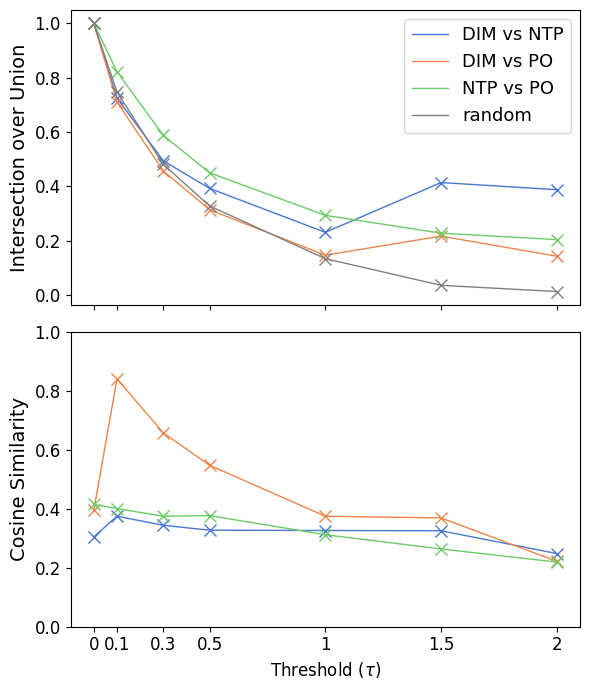

In [31]:
def get_sim(v1, v2):
    return t.cosine_similarity(v1, v2, dim=0)

def get_iou(v1, v2):
    intersection = t.logical_and(v1, v2).sum()
    union = t.logical_or(v1, v2).sum()
    return intersection / union

# measure sim between dim and po
dim_po_sims = []
dim_po_ious = []
for i in range(len(dim_vectors)):
    dim_po_sims.append(get_sim(dim_vectors[i], po_vectors[i]))
    observed_iou = get_iou(dim_vectors[i]!=0, po_vectors[i]!=0)
    dim_po_ious.append(observed_iou)
    avg_m = int(((dim_vectors[i]!=0).sum() + (po_vectors[i]!=0).sum()) / 2)
    n = len(dim_vectors[i])
    observed_k = int(observed_iou * 2 * avg_m / (1 + observed_iou))
    p_value = hypergeom.sf(observed_k - 1, n, avg_m, avg_m)
    print(rtols[i], p_value, observed_k, avg_m)

# measure sim between dim and ntp
dim_ntp_sims = []
dim_ntp_ious = []
for i in range(len(dim_vectors)):
    dim_ntp_sims.append(get_sim(dim_vectors[i], ntp_vectors[i]))
    observed_iou = get_iou(dim_vectors[i]!=0, ntp_vectors[i]!=0)
    dim_ntp_ious.append(observed_iou)
    avg_m = int(((dim_vectors[i]!=0).sum() + (ntp_vectors[i]!=0).sum()) / 2)
    n = len(dim_vectors[i])
    observed_k = int(observed_iou * 2 * avg_m / (1 + observed_iou))
    p_value = hypergeom.sf(observed_k - 1, n, avg_m, avg_m)
    print(rtols[i], p_value, observed_k, avg_m)

# measure sim between ntp and po
ntp_po_sims = []
ntp_po_ious = []
for i in range(len(dim_vectors)):
    ntp_po_sims.append(get_sim(ntp_vectors[i], po_vectors[i]))
    observed_iou = get_iou(ntp_vectors[i]!=0, po_vectors[i]!=0)
    ntp_po_ious.append(observed_iou)
    avg_m = int(((po_vectors[i]!=0).sum() + (ntp_vectors[i]!=0).sum()) / 2)
    n = len(ntp_vectors[i])
    observed_k = int(observed_iou * 2 * avg_m / (1 + observed_iou))
    p_value = hypergeom.sf(observed_k - 1, n, avg_m, avg_m)
    print(rtols[i], p_value, observed_k, avg_m)

# random IoU
random_ious = []
for i in range(len(dim_vectors)):
    m = ((ntp_vectors[i]!=0).sum() + (dim_vectors[i]!=0).sum() + (po_vectors[i]!=0).sum())/3
    n = len(ntp_vectors[i])
    random_ious.append(m / (2*n-m))

# --- combined plot ---
from matplotlib.lines import Line2D
palette = sns.color_palette("muted", 3)
x = rtols
y = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, (ax_iou, ax_sim) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

# bottom: cosine similarity
ax_sim.plot(x, dim_ntp_sims, color=palette[0], marker='x', markersize=8, linestyle='-', linewidth=1)
ax_sim.plot(x, dim_po_sims,  color=palette[1], marker='x', markersize=8, linestyle='-', linewidth=1)
ax_sim.plot(x, ntp_po_sims,  color=palette[2], marker='x', markersize=8, linestyle='-', linewidth=1)
ax_sim.set_yticks(y)
ax_sim.set_ylabel('Cosine Similarity', fontsize=14)
ax_sim.tick_params(axis='y', labelsize=12)
ax_sim.set_xticks(x)
ax_sim.set_xticklabels([rf'{r}' for r in x], fontsize=12)
ax_sim.set_xlabel(r'Threshold ($\tau$)', fontsize=12)

# top: IoU
ax_iou.plot(x, dim_ntp_ious, color=palette[0], marker='x', markersize=8, linestyle='-', linewidth=1, label='DIM vs NTP')
ax_iou.plot(x, dim_po_ious,  color=palette[1], marker='x', markersize=8, linestyle='-', linewidth=1, label='DIM vs PO')
ax_iou.plot(x, ntp_po_ious,  color=palette[2], marker='x', markersize=8, linestyle='-', linewidth=1, label='NTP vs PO')
ax_iou.plot(x, random_ious,  color='gray',      marker='x', markersize=8, linestyle='-', linewidth=1, label='random')
ax_iou.set_yticks(y)
ax_iou.set_ylabel('Intersection over Union', fontsize=14)
ax_iou.tick_params(axis='y', labelsize=12)

legend_handles = [
    Line2D([0], [0], color=palette[0], linewidth=1, label='DIM vs NTP'),
    Line2D([0], [0], color=palette[1], linewidth=1, label='DIM vs PO'),
    Line2D([0], [0], color=palette[2], linewidth=1, label='NTP vs PO'),
    Line2D([0], [0], color='gray',     linewidth=1, label='random'),
]
ax_iou.legend(handles=legend_handles, fontsize=13, loc='upper right')

plt.tight_layout()
plt.savefig('sparse_sim_iou_g2.pdf', bbox_inches='tight')
plt.show()


now plot sparsities of Llama 3.2 3B, which goes in appendix

In [5]:
model_path = 'meta-llama/Llama-3.2-3B-Instruct'
model_dims = model_dims_dict[model_path]

l3_dropouts = [0, 312, 969, 1591, 2564, 2954, 3050]
l3_rtol_results = get_sparse_results('rtol', rtols, "dim_logit", model_path)
l3_dropout_results = get_sparse_results('dropout', l3_dropouts, "dim_logit", model_path)

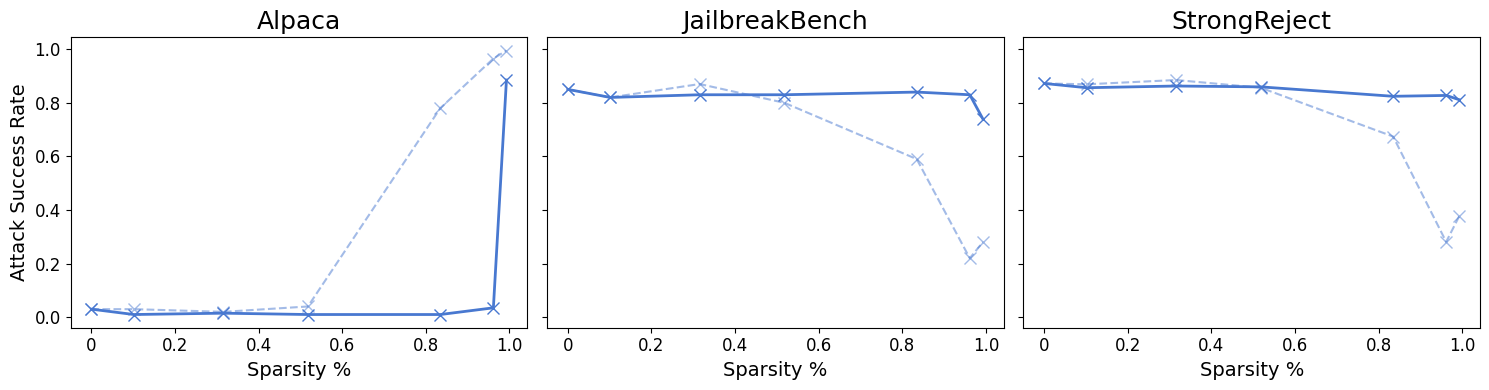

In [7]:
palette = sns.color_palette("muted", 1)

datasets   = ['Alpaca', 'JailbreakBench', 'StrongReject']
ds_indices = [0, 1, 2]
method='DIM'

# each results list is [(a_asr, jbb_asr, sr_asr), ...] with 6 entries

xs = [n/model_dims for n in l3_dropouts]
x_ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ds_name, ds_idx in zip(axes, datasets, ds_indices):
    rtol_vals = [r[ds_idx] for r in l3_rtol_results]
    dropout_vals = [r[ds_idx] for r in l3_dropout_results]

    ax.plot(xs, rtol_vals,    color=palette[0], linestyle='-', marker='x', markersize=8, linewidth=2,   label=f'{method} (rtol)')
    ax.plot(xs, dropout_vals, color=palette[0], linestyle='--', marker='x', markersize=8, linewidth=1.5, alpha=0.5, label=f'{method} (dropout)')

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticks, fontsize=12)
    ax.set_xlabel('Sparsity %', fontsize=14)
    ax.set_title(ds_name, fontsize=18)

axes[0].tick_params('y', labelsize=12)
axes[0].set_ylabel('Attack Success Rate', fontsize=14)

# plt.suptitle('Sparse Steering Vector Evaluation (Gemma 2 2B)', fontsize=13)
plt.tight_layout()
plt.savefig("sparsity_l3.pdf", bbox_inches='tight')
plt.show()
